<a href="https://colab.research.google.com/github/nmwiley808/csci164/blob/main/project/csci164%20Final%20Project%3A%20Applied%20Machine%20Learning%20with%20scikit-learn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Applied Machine Learning - Final Project

Course: CSCI 164 | Noah Wiley | Spring 2026

---

# Overview
This notebook walks through a complete machine learning workflow using Python and sckikit-learn across two real-world datasets

---

# Dataset 1 - Titanic Survival (Classification)
Using passenger data such such as age, sex, class, and fare. We can predict wheether a passenger survived. This is a binary classification problem.

# Dataset 2 - California Housing Prices (Regression)
Using census-level features like median income and location, we predict median house values. This is a regression problem.

---

# What to Expect
1. **Imports & Setup** – Load all necessary libraries
2. **Dataset 1: Titanic** – Load, explore, and preprocess the data
3. **Titanic Models** – Train Logistic Regression, Decision Tree, and k-NN
4. **Titanic Evaluation** – Confusion matrices, ROC curves, metrics comparison
5. **Titanic Tuning** – Optimize models using GridSearchCV
6. **Dataset 2: California Housing** – Load, explore, and preprocess the data
7. **Housing Models** – Train Linear Regression, Decision Tree, and k-NN
8. **Housing Evaluation** – Scatter plots, residual plots, metrics comparison
9. **Housing Tuning** – Optimize models using GridSearchCV
10. **Final Dashboard** – Side-by-side comparison of all models

---

# How to Run
Run each cell from top to bottom in order. All libraries are pre-installed in Google Colab.

In [6]:
# Setup

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, roc_curve,
    mean_absolute_error, mean_squared_error, r2_score
)

sns.set_theme(style='whitegrid', palette='muted')
np.random.seed(42)
print("Libraries loaded.")

Libraries loaded.


In [7]:
# Load Titanic via seaborn's built-in copy - no Kaggle Key needed
titanic_raw = sns.load_dataset('titanic')
print(titanic_raw.shape)
titanic_raw.head()

(891, 15)


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB
None

Missing values:
 survived         0
pclass           0
sex              0

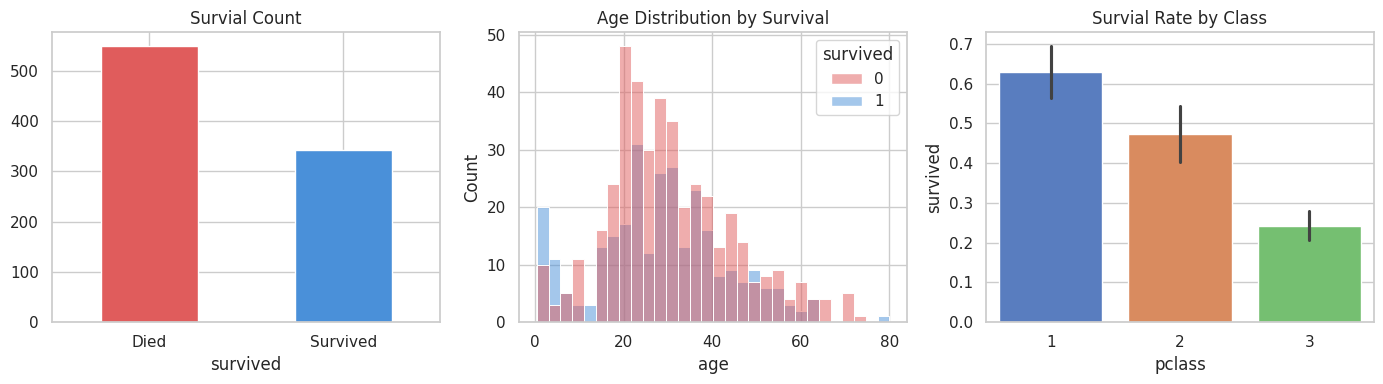

In [8]:
# Titanic Explore

print(titanic_raw.info())
print("\nMissing values:\n", titanic_raw.isnull().sum())
print("\nSurvival rate:", titanic_raw['survived'].mean().round(3))

fig, axes = plt.subplots(1, 3, figsize=(14,4))

titanic_raw['survived'].value_counts().plot(kind='bar', ax=axes[0], color=['#e05c5c', '#4a90d9'])
axes[0].set_title('Survial Count')
axes[0].set_xticklabels(['Died', 'Survived'], rotation=0)

sns.histplot(data=titanic_raw, x='age', hue='survived', bins=30, ax=axes[1], palette=['#e05c5c','#4a90d9'])
axes[1].set_title('Age Distribution by Survival')

sns.barplot(data=titanic_raw, x='pclass', y='survived', ax=axes[2], palette='muted')
axes[2].set_title('Survial Rate by Class')

plt.tight_layout()
plt.show()

In [9]:
# Titanic: Preprocessing

df_t = titanic_raw[['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked']].copy()

df_t['age'].fillna(df_t['age'].median(), inplace=True)
df_t['fare'].fillna(df_t['fare'].median(), inplace=True)
df_t.dropna(inplace=True)

df_t['sex'] = df_t['sex'].map({'male': 0, 'female': 1})
df_t['embarked'] = df_t['embarked'].map({'S': 0, 'C': 1, 'Q': 2})

df_t['family_size'] = df_t['sibsp'] + df_t['parch']
df_t['is_alone'] = (df_t['family_size'] == 0).astype(int)

X_t = df_t.drop('survived', axis=1)
y_t = df_t['survived']

X_train_t, X_test_t, y_train_t, y_test_t = train_test_split(
    X_t, y_t, test_size=0.2, random_state=42, stratify=y_t
)

print(f"Train size: {X_train_t.shape}, Test size: {X_test_t.shape}")
print(f"Class balance (train): {y_train_t.value_counts(normalize=True).round(3).to_dict()}")

Train size: (711, 9), Test size: (178, 9)
Class balance (train): {0: 0.617, 1: 0.383}


In [10]:
# Titanic: Train Three Models

clf_models = {
    'Logistic Regression': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', LogisticRegression(max_iter=1000, random_state=42))
    ]),
    'Decision Tree': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', DecisionTreeClassifier(random_state=42))
    ]),
    'k-NN': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', KNeighborsClassifier())
    ])
}

clf_results = {}
for name, model in clf_models.items():
    model.fit(X_train_t, y_train_t)
    y_pred  = model.predict(X_test_t)
    y_prob  = model.predict_proba(X_test_t)[:, 1]
    cv_scores = cross_val_score(model, X_t, y_t, cv=5, scoring='accuracy')
    clf_results[name] = {
        'model':     model,
        'y_pred':    y_pred,
        'y_prob':    y_prob,
        'accuracy':  accuracy_score(y_test_t, y_pred),
        'precision': precision_score(y_test_t, y_pred),
        'recall':    recall_score(y_test_t, y_pred),
        'f1':        f1_score(y_test_t, y_pred),
        'roc_auc':   roc_auc_score(y_test_t, y_prob),
        'cv_mean':   cv_scores.mean(),
        'cv_std':    cv_scores.std(),
    }
    print(f"{name:22s} | Acc={clf_results[name]['accuracy']:.3f} "
          f"F1={clf_results[name]['f1']:.3f} "
          f"AUC={clf_results[name]['roc_auc']:.3f} "
          f"CV={clf_results[name]['cv_mean']:.3f}±{clf_results[name]['cv_std']:.3f}")

Logistic Regression    | Acc=0.815 F1=0.744 AUC=0.865 CV=0.792±0.016
Decision Tree          | Acc=0.747 F1=0.672 AUC=0.728 CV=0.774±0.021
k-NN                   | Acc=0.781 F1=0.702 AUC=0.832 CV=0.808±0.020


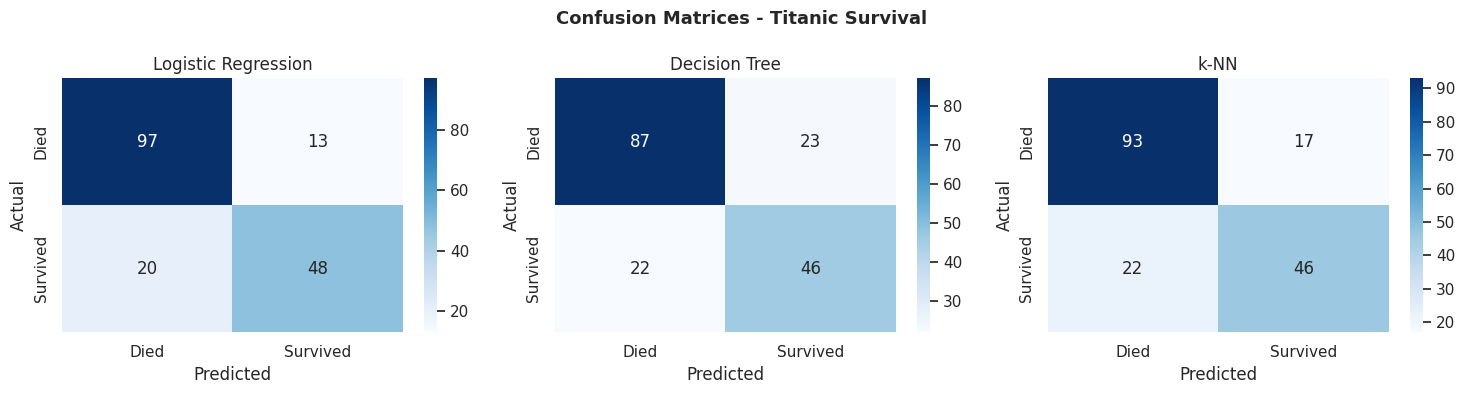

In [11]:
# Titanic: Confusion Matrices

fig, axes = plt.subplots(1, 3, figsize=(15,4))
fig.suptitle('Confusion Matrices - Titanic Survival', fontsize=13, fontweight='bold')

for ax, (name, res) in zip(axes, clf_results.items()):
  cm = confusion_matrix(y_test_t, res['y_pred'])
  sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
              xticklabels=['Died', 'Survived'],
              yticklabels=['Died', 'Survived'])
  ax.set_title(name)
  ax.set_xlabel('Predicted')
  ax.set_ylabel('Actual')

plt.tight_layout()
plt.show()

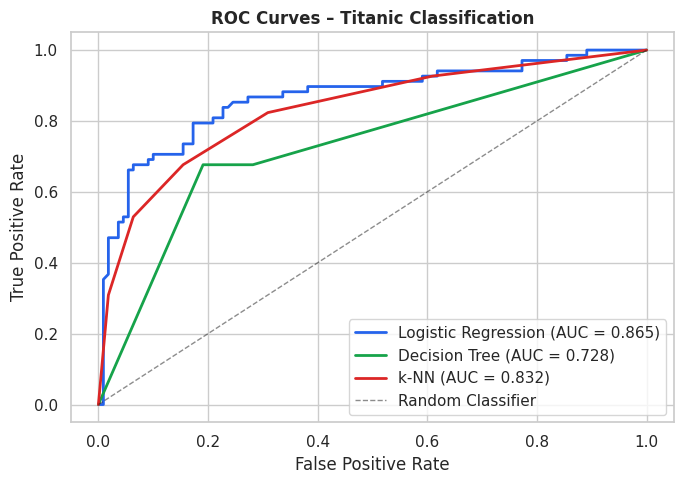

In [12]:
# Titanic: ROC Curves

fig, ax = plt.subplots(figsize=(7, 5))
colors = ['#2563eb', '#16a34a', '#dc2626']

for (name, res), color in zip(clf_results.items(), colors):
  fpr, tpr, _ = roc_curve(y_test_t, res['y_prob'])
  ax.plot(fpr, tpr, lw=2, color=color,
            label=f"{name} (AUC = {res['roc_auc']:.3f})")

ax.plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.5, label='Random Classifier')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves – Titanic Classification', fontweight='bold')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

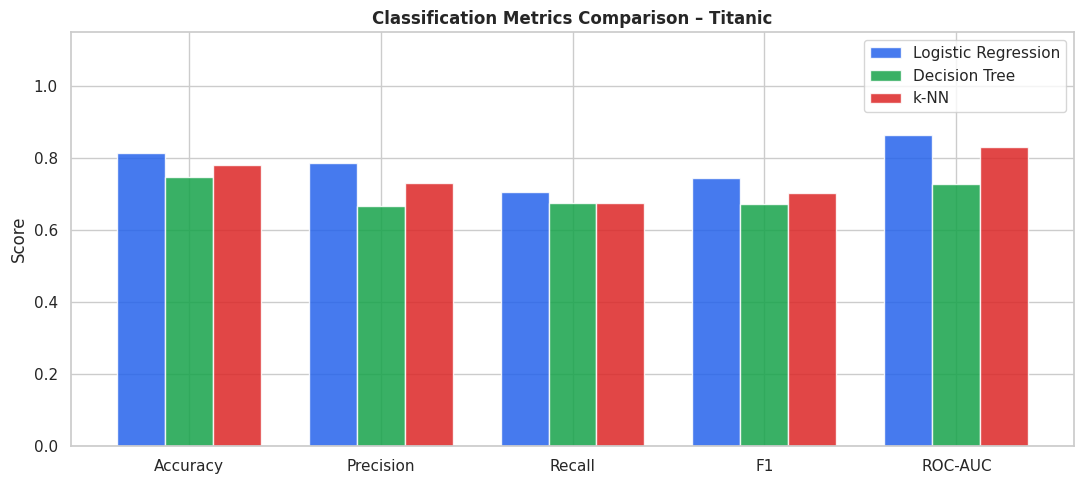

In [13]:
# Titanic: Metrics Bar Chart

metrics = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']
x = np.arange(len(metrics))
width = 0.25

fig, ax = plt.subplots(figsize=(11,5))
for i, (name, color) in enumerate(zip(clf_results.keys(), colors)):
  vals = [clf_results[name][m] for m in metrics]
  ax.bar(x + i * width, vals, width, label=name, color=color, alpha=0.85)

ax.set_xticks(x + width)
ax.set_xticklabels(['Accuracy', 'Precision', 'Recall', 'F1', 'ROC-AUC'])
ax.set_ylim(0, 1.15)
ax.set_ylabel('Score')
ax.set_title('Classification Metrics Comparison – Titanic', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

In [14]:
# Titanic: Hyperparameter Tuning

dt_param_grid = {
    'clf__max_depth': [3, 5, 7, 10, None],
    'clf__min_samples_split': [2, 5, 10],
    'clf__min_samples_leaf': [1, 2, 4]
}

gs_dt = GridSearchCV(clf_models['Decision Tree'], dt_param_grid,
                     cv = 5, scoring='accuracy', n_jobs=-1)
gs_dt.fit(X_train_t, y_train_t)
print("Best Decision Tree params:", gs_dt.best_params_)
print("Best CV accuracy:         ", round(gs_dt.best_score_, 4))

knn_param_grid = {
    'clf__n_neighbors': [3, 5, 7, 9, 11, 15],
    'clf__weights':     ['uniform', 'distance'],
    'clf__metric':      ['euclidean', 'manhattan']
}

gs_knn = GridSearchCV(clf_models['k-NN'], knn_param_grid,
                      cv=5, scoring='accuracy', n_jobs=-1)
gs_knn.fit(X_train_t, y_train_t)
print("Best k-NN params:         ", gs_knn.best_params_)
print("Best CV accuracy:         ", round(gs_knn.best_score_, 4))

tuned_models = {
    'Decision Tree (Tuned)': gs_dt.best_estimator_,
    'k-NN (Tuned)':          gs_knn.best_estimator_
}
print("\nTuned model test-set results:")
for name, model in tuned_models.items():
    y_pred = model.predict(X_test_t)
    y_prob = model.predict_proba(X_test_t)[:, 1]
    print(f"  {name:25s} | Acc={accuracy_score(y_test_t,y_pred):.3f} "
          f"F1={f1_score(y_test_t,y_pred):.3f} "
          f"AUC={roc_auc_score(y_test_t,y_prob):.3f}")

Best Decision Tree params: {'clf__max_depth': 5, 'clf__min_samples_leaf': 1, 'clf__min_samples_split': 10}
Best CV accuracy:          0.8158
Best k-NN params:          {'clf__metric': 'manhattan', 'clf__n_neighbors': 9, 'clf__weights': 'uniform'}
Best CV accuracy:          0.8115

Tuned model test-set results:
  Decision Tree (Tuned)     | Acc=0.770 F1=0.655 AUC=0.825
  k-NN (Tuned)              | Acc=0.787 F1=0.721 AUC=0.846


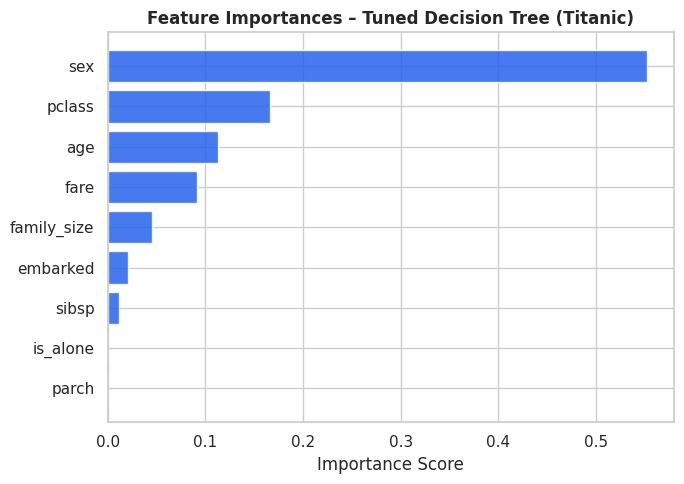

In [15]:
# Titanic: Feature Importances

best_dt_clf = gs_dt.best_estimator_
importances = best_dt_clf.named_steps['clf'].feature_importances_
feat_df = pd.DataFrame({'feature': X_t.columns, 'importance': importances})
feat_df = feat_df.sort_values('importance', ascending=True)

fig, ax = plt.subplots(figsize=(7, 5))
ax.barh(feat_df['feature'], feat_df['importance'], color='#2563eb', alpha=0.85)
ax.set_xlabel('Importance Score')
ax.set_title('Feature Importances – Tuned Decision Tree (Titanic)', fontweight='bold')
plt.tight_layout()
plt.show()

In [16]:
# Classification Summary Table

summary_rows = []
for name, res in clf_results.items():
    summary_rows.append({
        'Model':     name,
        'Accuracy':  round(res['accuracy'],  3),
        'Precision': round(res['precision'], 3),
        'Recall':    round(res['recall'],    3),
        'F1':        round(res['f1'],        3),
        'ROC-AUC':   round(res['roc_auc'],   3),
        'CV Mean':   round(res['cv_mean'],   3),
        'CV Std':    round(res['cv_std'],    3),
    })
for name, model in tuned_models.items():
    yp = model.predict(X_test_t)
    yprob = model.predict_proba(X_test_t)[:,1]
    cv = cross_val_score(model, X_t, y_t, cv=5, scoring='accuracy')
    summary_rows.append({
        'Model':     name,
        'Accuracy':  round(accuracy_score(y_test_t,yp),3),
        'Precision': round(precision_score(y_test_t,yp),3),
        'Recall':    round(recall_score(y_test_t,yp),3),
        'F1':        round(f1_score(y_test_t,yp),3),
        'ROC-AUC':   round(roc_auc_score(y_test_t,yprob),3),
        'CV Mean':   round(cv.mean(),3),
        'CV Std':    round(cv.std(),3),
    })

clf_summary = pd.DataFrame(summary_rows)
print(clf_summary.to_string(index=False))

                Model  Accuracy  Precision  Recall    F1  ROC-AUC  CV Mean  CV Std
  Logistic Regression     0.815      0.787   0.706 0.744    0.865    0.792   0.016
        Decision Tree     0.747      0.667   0.676 0.672    0.728    0.774   0.021
                 k-NN     0.781      0.730   0.676 0.702    0.832    0.808   0.020
Decision Tree (Tuned)     0.770      0.765   0.574 0.655    0.825    0.818   0.029
         k-NN (Tuned)     0.787      0.721   0.721 0.721    0.846    0.799   0.031


In [17]:
# Load California Housing

housing = fetch_california_housing(as_frame=True)
df_h = housing.frame.copy()

print(df_h.shape)
print(df_h.describe().round(2))
df_h.head()

(20640, 9)
         MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  \
count  20640.00  20640.00  20640.00   20640.00    20640.00  20640.00   
mean       3.87     28.64      5.43       1.10     1425.48      3.07   
std        1.90     12.59      2.47       0.47     1132.46     10.39   
min        0.50      1.00      0.85       0.33        3.00      0.69   
25%        2.56     18.00      4.44       1.01      787.00      2.43   
50%        3.53     29.00      5.23       1.05     1166.00      2.82   
75%        4.74     37.00      6.05       1.10     1725.00      3.28   
max       15.00     52.00    141.91      34.07    35682.00   1243.33   

       Latitude  Longitude  MedHouseVal  
count  20640.00   20640.00     20640.00  
mean      35.63    -119.57         2.07  
std        2.14       2.00         1.15  
min       32.54    -124.35         0.15  
25%       33.93    -121.80         1.20  
50%       34.26    -118.49         1.80  
75%       37.71    -118.01         2.65  
max 

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


Missing values:
 MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64


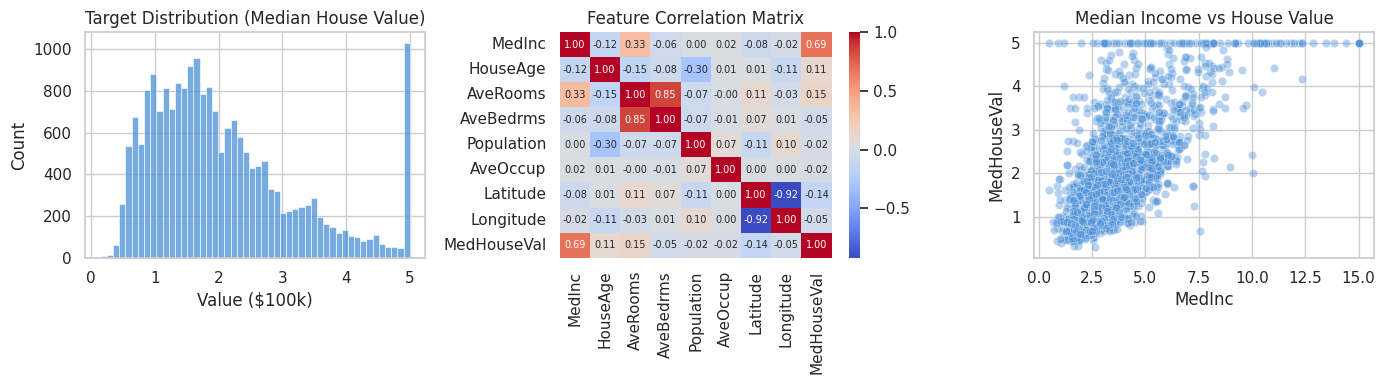

In [18]:
# Housing: Explore

print("Missing values:\n", df_h.isnull().sum())

fig, axes = plt.subplots(1, 3, figsize=(14,4))

sns.histplot(df_h['MedHouseVal'], bins=50, ax=axes[0], color='#4a90d9')
axes[0].set_title('Target Distribution (Median House Value)')
axes[0].set_xlabel('Value ($100k)')

sns.heatmap(df_h.corr().round(2), annot=True, cmap='coolwarm',
            fmt='.2f', ax=axes[1], annot_kws={'size': 7})
axes[1].set_title('Feature Correlation Matrix')

sns.scatterplot(data=df_h.sample(2000), x='MedInc', y='MedHouseVal',
                alpha=0.4, ax=axes[2], color='#4a90d9')
axes[2].set_title('Median Income vs House Value')

plt.tight_layout()
plt.show()

In [19]:
# Housing: Preprocessing & Split

X_h = df_h.drop('MedHouseVal', axis=1)
y_h = df_h['MedHouseVal']

X_train_h, X_test_h, y_train_h, y_test_h = train_test_split(
    X_h, y_h, test_size=0.2, random_state=42
)

print(f"Train: {X_train_h.shape} | Test: {X_test_h.shape}")
print(f"Target range: {y_h.min():.2f} – {y_h.max():.2f}, Mean: {y_h.mean():.2f}")

Train: (16512, 8) | Test: (4128, 8)
Target range: 0.15 – 5.00, Mean: 2.07


In [20]:
# Housing: Train Three Models
reg_models = {
    'Linear Regression': Pipeline([
        ('scaler', StandardScaler()),
        ('reg', LinearRegression())
    ]),
    'Decision Tree': Pipeline([
        ('scaler', StandardScaler()),
        ('reg', DecisionTreeRegressor(random_state=42))
    ]),
    'k-NN': Pipeline([
        ('scaler', StandardScaler()),
        ('reg', KNeighborsRegressor())
    ])
}

reg_results = {}
for name, model in reg_models.items():
    model.fit(X_train_h, y_train_h)
    y_pred    = model.predict(X_test_h)
    cv_scores = cross_val_score(model, X_h, y_h, cv=5, scoring='r2')
    reg_results[name] = {
        'model':   model,
        'y_pred':  y_pred,
        'mae':     mean_absolute_error(y_test_h, y_pred),
        'mse':     mean_squared_error(y_test_h, y_pred),
        'rmse':    np.sqrt(mean_squared_error(y_test_h, y_pred)),
        'r2':      r2_score(y_test_h, y_pred),
        'cv_mean': cv_scores.mean(),
        'cv_std':  cv_scores.std(),
    }
    print(f"{name:22s} | R²={reg_results[name]['r2']:.3f}  "
          f"RMSE={reg_results[name]['rmse']:.3f}  "
          f"MAE={reg_results[name]['mae']:.3f}  "
          f"CV={reg_results[name]['cv_mean']:.3f}±{reg_results[name]['cv_std']:.3f}")

Linear Regression      | R²=0.576  RMSE=0.746  MAE=0.533  CV=0.553±0.062
Decision Tree          | R²=0.623  RMSE=0.703  MAE=0.454  CV=0.355±0.085
k-NN                   | R²=0.670  RMSE=0.658  MAE=0.446  CV=0.521±0.044


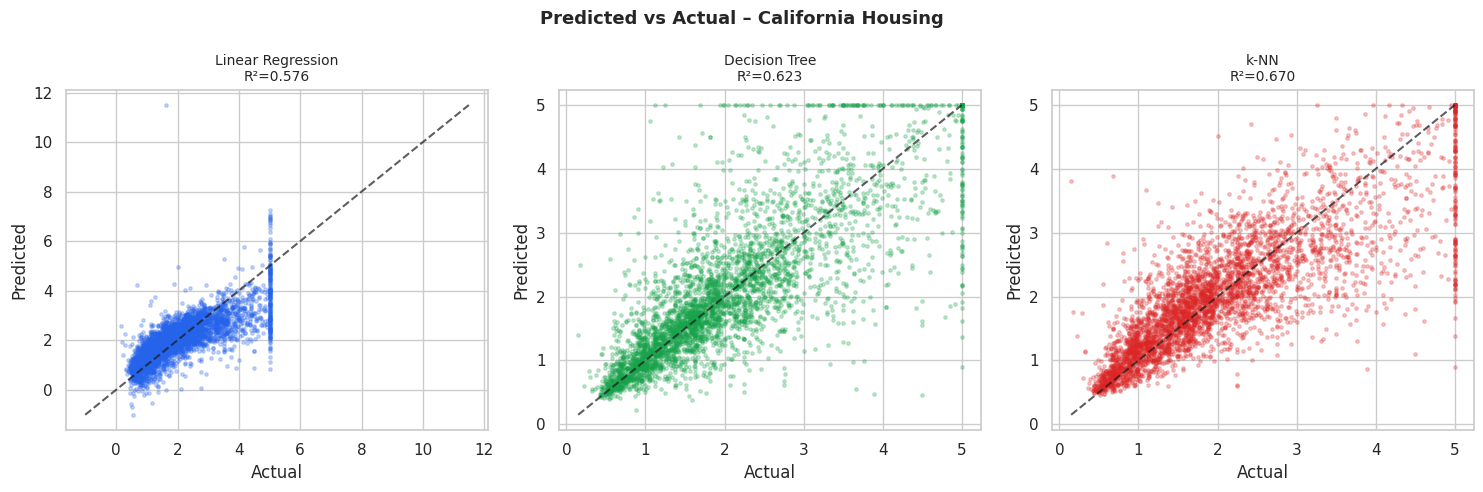

In [21]:
# Housing: Predicted vs Actual

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Predicted vs Actual – California Housing', fontsize=13, fontweight='bold')
colors_reg = ['#2563eb', '#16a34a', '#dc2626']

for ax, (name, res), color in zip(axes, reg_results.items(), colors_reg):
    ax.scatter(y_test_h, res['y_pred'], alpha=0.25, s=6, color=color)
    lims = [min(y_test_h.min(), res['y_pred'].min()),
            max(y_test_h.max(), res['y_pred'].max())]
    ax.plot(lims, lims, 'k--', lw=1.5, alpha=0.7)
    ax.set_xlabel('Actual')
    ax.set_ylabel('Predicted')
    ax.set_title(f"{name}\nR²={res['r2']:.3f}", fontsize=10)

plt.tight_layout()
plt.show()

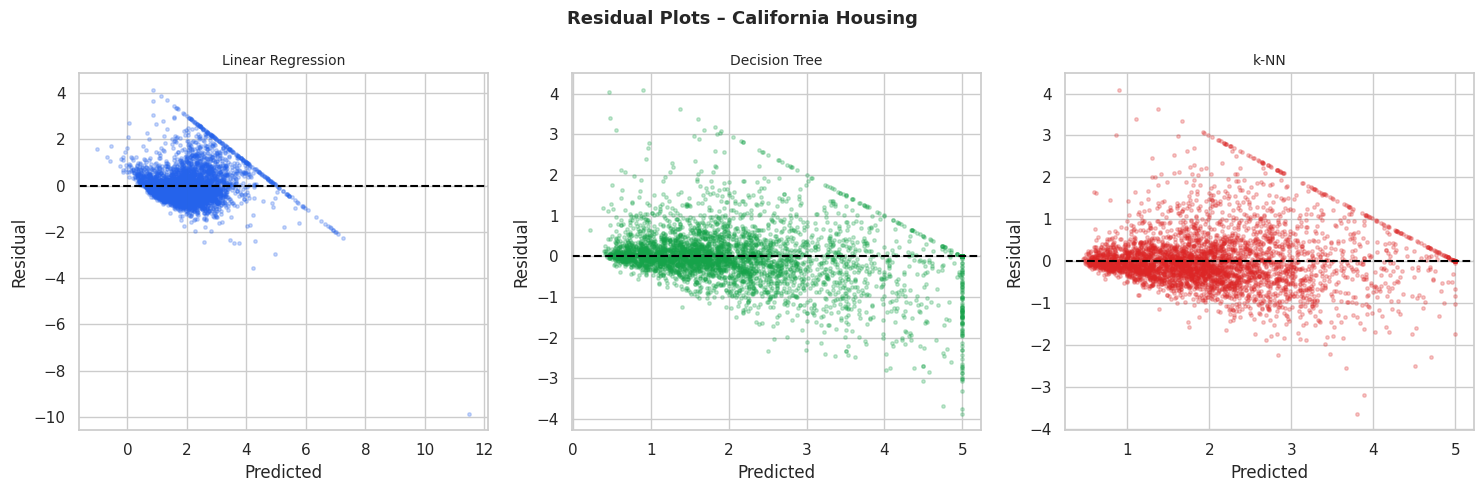

In [22]:
# Housing: Residual Plots

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Residual Plots – California Housing', fontsize=13, fontweight='bold')

for ax, (name, res), color in zip(axes, reg_results.items(), colors_reg):
    residuals = y_test_h.values - res['y_pred']
    ax.scatter(res['y_pred'], residuals, alpha=0.25, s=6, color=color)
    ax.axhline(0, color='black', lw=1.5, linestyle='--')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Residual')
    ax.set_title(name, fontsize=10)

plt.tight_layout()
plt.show()

In [23]:
# Housing: Hyperparameter Tuning

dt_reg_params = {
    'reg__max_depth':         [3, 5, 7, 10, None],
    'reg__min_samples_split': [2, 5, 10],
    'reg__min_samples_leaf':  [1, 2, 4]
}
gs_dt_reg = GridSearchCV(reg_models['Decision Tree'], dt_reg_params,
                         cv=5, scoring='r2', n_jobs=-1)
gs_dt_reg.fit(X_train_h, y_train_h)
print("Best Decision Tree Regressor params:", gs_dt_reg.best_params_)
print("Best CV R²:", round(gs_dt_reg.best_score_, 4))

knn_reg_params = {
    'reg__n_neighbors': [3, 5, 7, 9, 11, 15],
    'reg__weights':     ['uniform', 'distance'],
    'reg__metric':      ['euclidean', 'manhattan']
}
gs_knn_reg = GridSearchCV(reg_models['k-NN'], knn_reg_params,
                          cv=5, scoring='r2', n_jobs=-1)
gs_knn_reg.fit(X_train_h, y_train_h)
print("\nBest k-NN Regressor params:", gs_knn_reg.best_params_)
print("Best CV R²:", round(gs_knn_reg.best_score_, 4))

tuned_reg_models = {
    'Decision Tree (Tuned)': gs_dt_reg.best_estimator_,
    'k-NN (Tuned)':          gs_knn_reg.best_estimator_
}
print("\nTuned regression test-set results:")
for name, model in tuned_reg_models.items():
    yp = model.predict(X_test_h)
    print(f"  {name:25s} | R²={r2_score(y_test_h,yp):.3f}  "
          f"RMSE={np.sqrt(mean_squared_error(y_test_h,yp)):.3f}  "
          f"MAE={mean_absolute_error(y_test_h,yp):.3f}")

Best Decision Tree Regressor params: {'reg__max_depth': 10, 'reg__min_samples_leaf': 4, 'reg__min_samples_split': 2}
Best CV R²: 0.7099

Best k-NN Regressor params: {'reg__metric': 'manhattan', 'reg__n_neighbors': 9, 'reg__weights': 'distance'}
Best CV R²: 0.7313

Tuned regression test-set results:
  Decision Tree (Tuned)     | R²=0.689  RMSE=0.639  MAE=0.431
  k-NN (Tuned)              | R²=0.722  RMSE=0.603  MAE=0.406


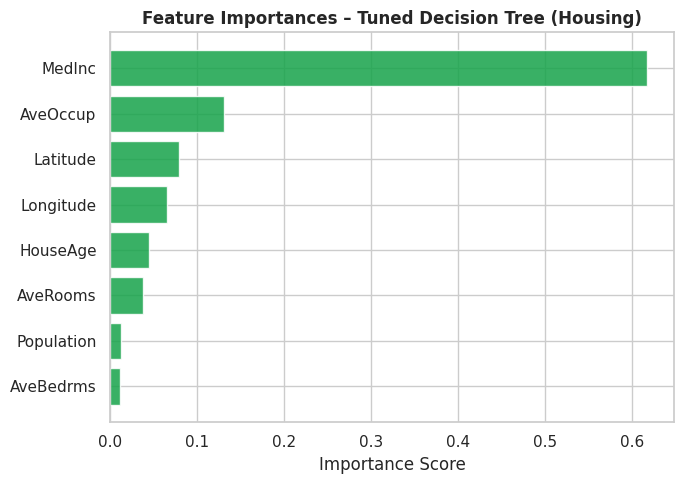

In [24]:
# Housing: Feature Importances

best_dt_reg = gs_dt_reg.best_estimator_
importances_reg = best_dt_reg.named_steps['reg'].feature_importances_
feat_df_reg = pd.DataFrame({'feature': X_h.columns, 'importance': importances_reg})
feat_df_reg = feat_df_reg.sort_values('importance', ascending=True)

fig, ax = plt.subplots(figsize=(7, 5))
ax.barh(feat_df_reg['feature'], feat_df_reg['importance'], color='#16a34a', alpha=0.85)
ax.set_xlabel('Importance Score')
ax.set_title('Feature Importances – Tuned Decision Tree (Housing)', fontweight='bold')
plt.tight_layout()
plt.show()

In [25]:
# Housing: Regression Summary Table

reg_summary_rows = []
for name, res in reg_results.items():
    reg_summary_rows.append({
        'Model':   name,
        'MAE':     round(res['mae'],     3),
        'MSE':     round(res['mse'],     3),
        'RMSE':    round(res['rmse'],    3),
        'R2':      round(res['r2'],      3),
        'CV Mean': round(res['cv_mean'], 3),
        'CV Std':  round(res['cv_std'],  3),
    })
for name, model in tuned_reg_models.items():
    yp = model.predict(X_test_h)
    cv = cross_val_score(model, X_h, y_h, cv=5, scoring='r2')
    reg_summary_rows.append({
        'Model':   name,
        'MAE':     round(mean_absolute_error(y_test_h, yp),  3),
        'MSE':     round(mean_squared_error(y_test_h, yp),   3),
        'RMSE':    round(np.sqrt(mean_squared_error(y_test_h, yp)), 3),
        'R2':      round(r2_score(y_test_h, yp),             3),
        'CV Mean': round(cv.mean(), 3),
        'CV Std':  round(cv.std(),  3),
    })

reg_summary = pd.DataFrame(reg_summary_rows)
print(reg_summary.to_string(index=False))

                Model   MAE   MSE  RMSE    R2  CV Mean  CV Std
    Linear Regression 0.533 0.556 0.746 0.576    0.553   0.062
        Decision Tree 0.454 0.494 0.703 0.623    0.355   0.085
                 k-NN 0.446 0.432 0.658 0.670    0.521   0.044
Decision Tree (Tuned) 0.431 0.408 0.639 0.689    0.520   0.103
         k-NN (Tuned) 0.406 0.364 0.603 0.722    0.562   0.047


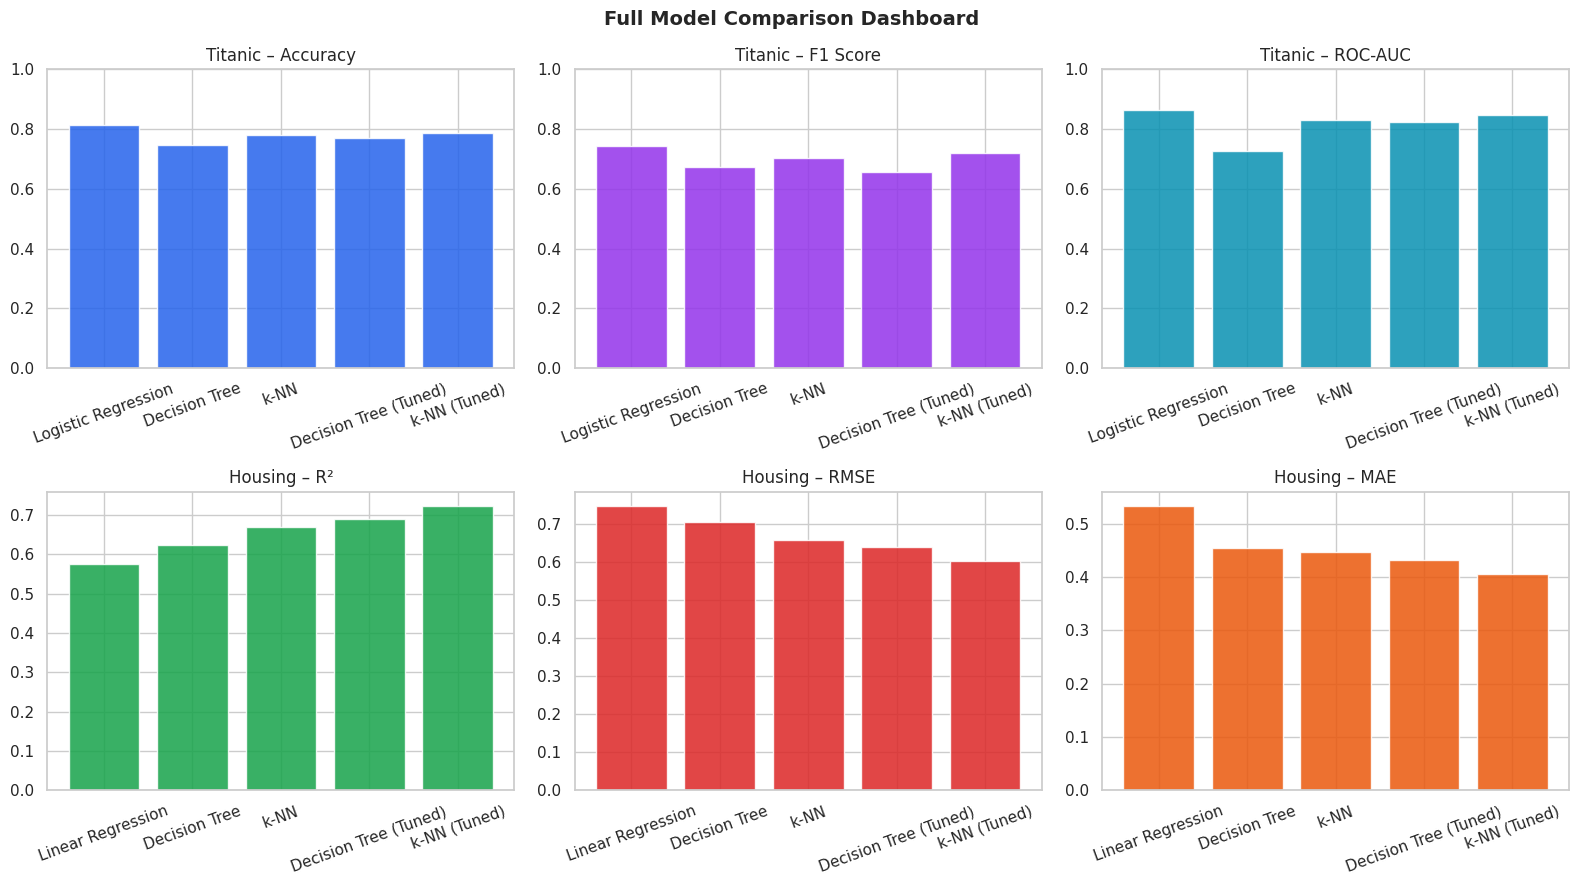


Project complete.


In [26]:
# Final Dashboard

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle('Full Model Comparison Dashboard', fontsize=14, fontweight='bold')

axes[0,0].bar(clf_summary['Model'], clf_summary['Accuracy'],  color='#2563eb', alpha=0.85)
axes[0,0].set_title('Titanic – Accuracy');  axes[0,0].tick_params(axis='x', rotation=20); axes[0,0].set_ylim(0,1)

axes[0,1].bar(clf_summary['Model'], clf_summary['F1'],        color='#9333ea', alpha=0.85)
axes[0,1].set_title('Titanic – F1 Score'); axes[0,1].tick_params(axis='x', rotation=20); axes[0,1].set_ylim(0,1)

axes[0,2].bar(clf_summary['Model'], clf_summary['ROC-AUC'],   color='#0891b2', alpha=0.85)
axes[0,2].set_title('Titanic – ROC-AUC'); axes[0,2].tick_params(axis='x', rotation=20); axes[0,2].set_ylim(0,1)

axes[1,0].bar(reg_summary['Model'], reg_summary['R2'],   color='#16a34a', alpha=0.85)
axes[1,0].set_title('Housing – R²');   axes[1,0].tick_params(axis='x', rotation=20)

axes[1,1].bar(reg_summary['Model'], reg_summary['RMSE'], color='#dc2626', alpha=0.85)
axes[1,1].set_title('Housing – RMSE'); axes[1,1].tick_params(axis='x', rotation=20)

axes[1,2].bar(reg_summary['Model'], reg_summary['MAE'],  color='#ea580c', alpha=0.85)
axes[1,2].set_title('Housing – MAE');  axes[1,2].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.show()

print("\nProject complete.")